# Phần 2.2 - Low-pass và High-pass Filter

Notebook chia theo từng bộ lọc: tạo kernel, áp dụng, quan sát và so sánh. Ô cuối xử lý toàn bộ ảnh trong `images/` và ghi kết quả vào `results/`.

# Setup và đọc ảnh

In [24]:
from pathlib import Path
import csv

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [25]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "images").exists():
    PROJECT_DIR = PROJECT_DIR / "part2_filters"

INPUT_DIR = PROJECT_DIR / "images"
OUTPUT_DIR = PROJECT_DIR / "results"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}
CUSTOM_IMAGE_NAME = "urban.png"

image_paths = sorted(
    path for path in INPUT_DIR.iterdir()
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
    and path.name != "source_contact_sheet.png"
)
assert image_paths, "Không tìm thấy ảnh hợp lệ trong images/."

Ảnh minh họa: urban.png
Kích thước: 860 x 574 pixels


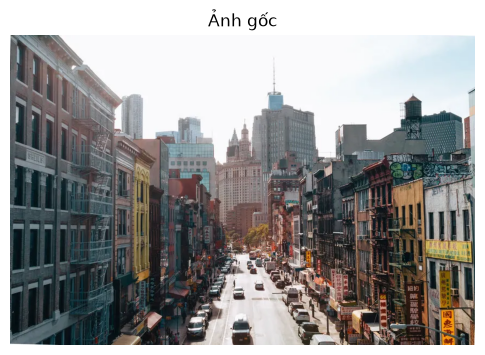

In [26]:
primary_path = next(
    (path for path in image_paths if path.name.lower() == CUSTOM_IMAGE_NAME),
    image_paths[0],
)

image_bgr = cv2.imread(str(primary_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("Ảnh minh họa:", primary_path.name)
print("Kích thước:", image_bgr.shape[1], "x", image_bgr.shape[0], "pixels")

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()

# Hàm metric

MSE đo mức ảnh lọc thay đổi so với ảnh gốc. Edge energy là trung bình độ lớn gradient Sobel, phản ánh lượng biên và texture còn lại.

In [27]:
def normalized_mse(original, filtered):
    original = original.astype(np.float32) / 255.0
    filtered = filtered.astype(np.float32) / 255.0
    return float(np.mean((original - filtered) ** 2))

def edge_energy(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    return float(cv2.magnitude(gx, gy).mean())

# Mean filter 5x5

In [28]:
KERNEL_SIZE = 5
mean_kernel = np.ones((KERNEL_SIZE, KERNEL_SIZE), dtype=np.float32) / 25
print(mean_kernel)
print("Tổng trọng số:", mean_kernel.sum())

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]
Tổng trọng số: 1.0


## Áp dụng kernel bằng `filter2D`

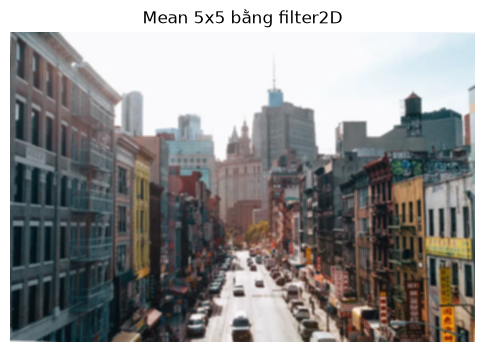

In [29]:
mean_manual = cv2.filter2D(image_rgb, -1, mean_kernel, borderType=cv2.BORDER_REFLECT)
plt.figure(figsize=(6,6)); plt.imshow(mean_manual); plt.title("Mean 5x5 bằng filter2D"); plt.axis("off"); plt.show()

## Áp dụng Mean bằng `cv2.blur` và so sánh

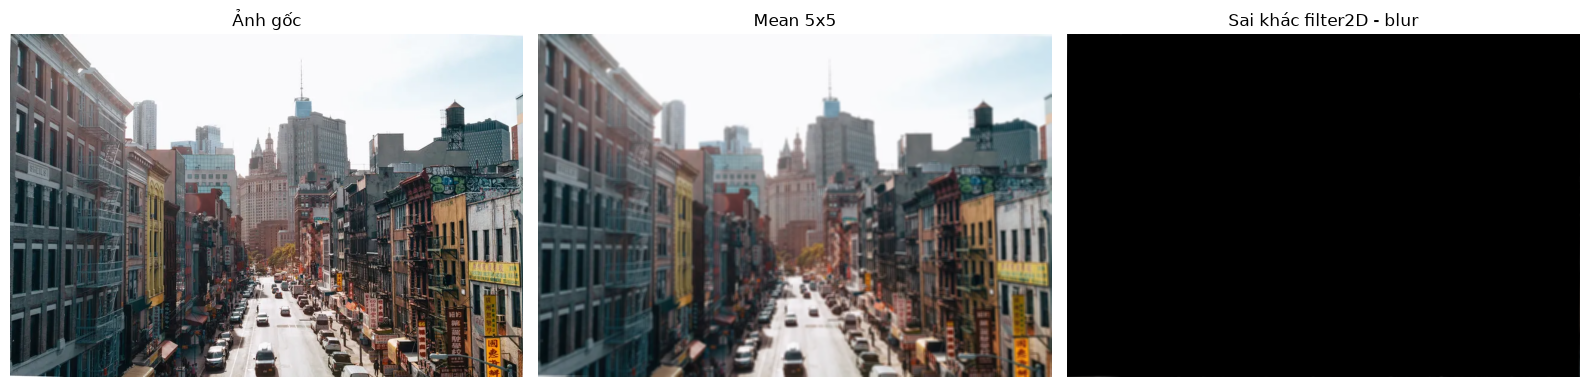

In [30]:
mean_rgb = cv2.blur(image_rgb, (KERNEL_SIZE, KERNEL_SIZE))
diff_mean = cv2.absdiff(mean_manual, mean_rgb)
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, img, title in zip(axes, [image_rgb, mean_rgb, diff_mean], ["Ảnh gốc", "Mean 5x5", "Sai khác filter2D - blur"]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Gaussian filter 5x5, sigma = 0 theo cấu hình OpenCV

In [31]:
SIGMA = 0.0
# sigmaX=0 để OpenCV tự suy ra sigma từ kernel 5x5.
g1 = cv2.getGaussianKernel(KERNEL_SIZE, SIGMA)
gaussian_kernel = g1 @ g1.T
print(np.round(gaussian_kernel, 4))
print("Tổng trọng số:", gaussian_kernel.sum())

[[0.0039 0.0156 0.0234 0.0156 0.0039]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0234 0.0938 0.1406 0.0938 0.0234]
 [0.0156 0.0625 0.0938 0.0625 0.0156]
 [0.0039 0.0156 0.0234 0.0156 0.0039]]
Tổng trọng số: 1.0


## Áp dụng Gaussian thủ công và bằng OpenCV

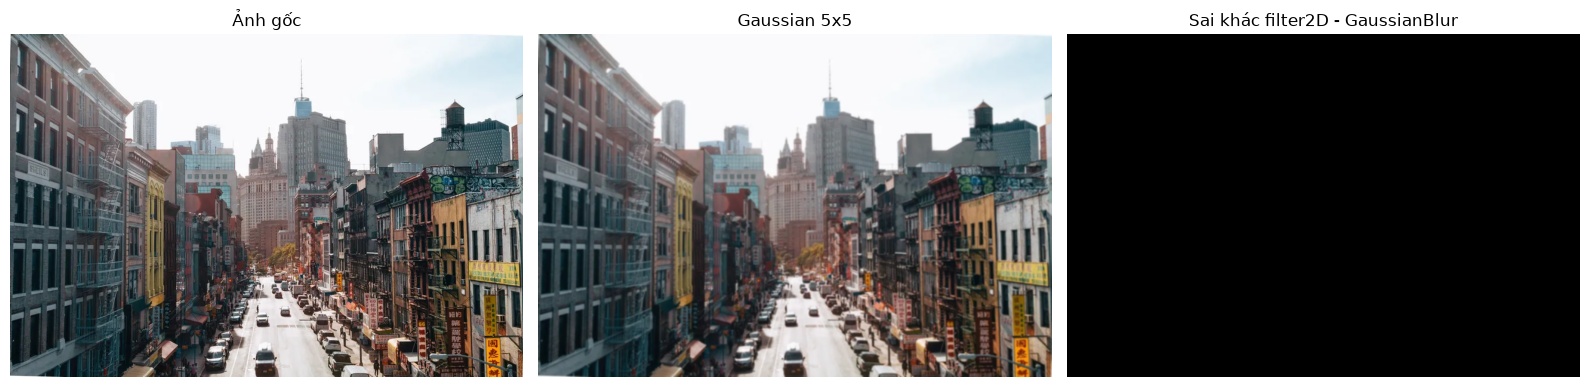

In [32]:
gaussian_manual = cv2.filter2D(image_rgb, -1, gaussian_kernel, borderType=cv2.BORDER_REFLECT)
gaussian_rgb = cv2.GaussianBlur(image_rgb, (KERNEL_SIZE, KERNEL_SIZE), SIGMA, sigmaY=SIGMA, borderType=cv2.BORDER_REFLECT)
diff_gaussian = cv2.absdiff(gaussian_manual, gaussian_rgb)
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, img, title in zip(axes, [image_rgb, gaussian_rgb, diff_gaussian], ["Ảnh gốc", "Gaussian 5x5", "Sai khác filter2D - GaussianBlur"]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# So sánh Mean và Gaussian

Mean: MSE=0.004230, edge energy=0.159224
Gaussian: MSE=0.002110, edge energy=0.198451


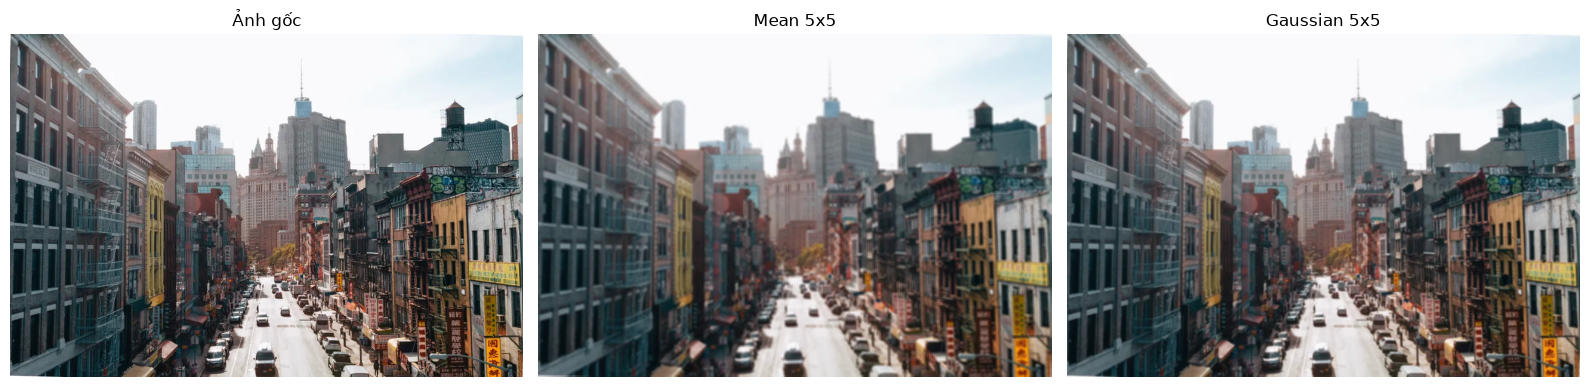

In [33]:
mean_gray = cv2.cvtColor(mean_rgb, cv2.COLOR_RGB2GRAY)
gaussian_gray = cv2.cvtColor(gaussian_rgb, cv2.COLOR_RGB2GRAY)
for name, img in [("Mean", mean_gray), ("Gaussian", gaussian_gray)]:
    print(f"{name}: MSE={normalized_mse(image_gray, img):.6f}, edge energy={edge_energy(img.astype(np.float32)/255):.6f}")
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax,img,title in zip(axes,[image_rgb,mean_rgb,gaussian_rgb],["Ảnh gốc","Mean 5x5","Gaussian 5x5"]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Laplacian High-pass Filter

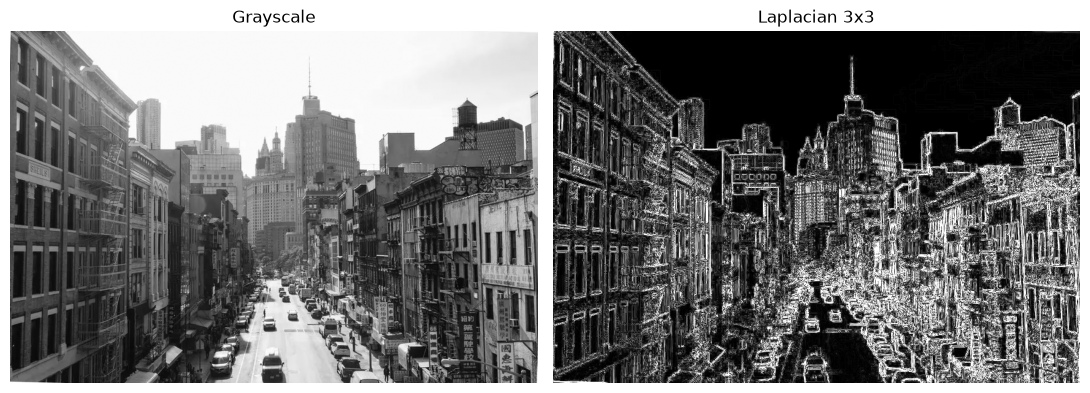

In [34]:
laplacian = cv2.convertScaleAbs(cv2.Laplacian(image_gray, cv2.CV_64F, ksize=3))
fig, axes = plt.subplots(1,2,figsize=(11,5))
for ax,img,title in zip(axes,[image_gray,laplacian],["Grayscale","Laplacian 3x3"]):
    ax.imshow(img,cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Sobel X, Sobel Y và Sobel magnitude

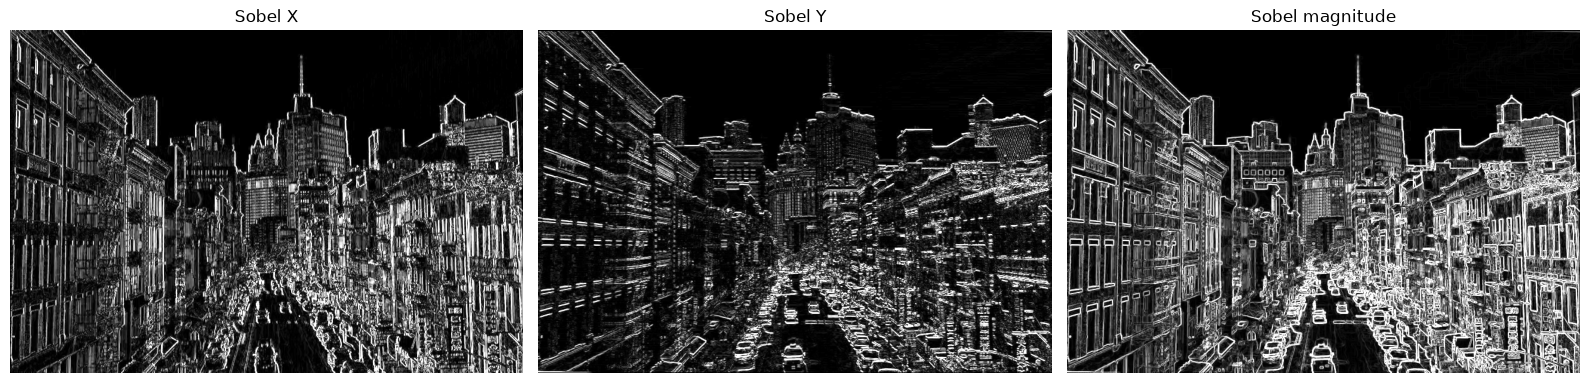

In [35]:
sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32)))
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax,img,title in zip(axes,[cv2.convertScaleAbs(sobel_x),cv2.convertScaleAbs(sobel_y),sobel],["Sobel X","Sobel Y","Sobel magnitude"]):
    ax.imshow(img,cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

# Bộ lọc custom 3x3

[[0.08333334 0.16666667 0.08333334]
 [0.16666667 0.         0.16666667]
 [0.08333334 0.16666667 0.08333334]]
Tổng trọng số: 1.0


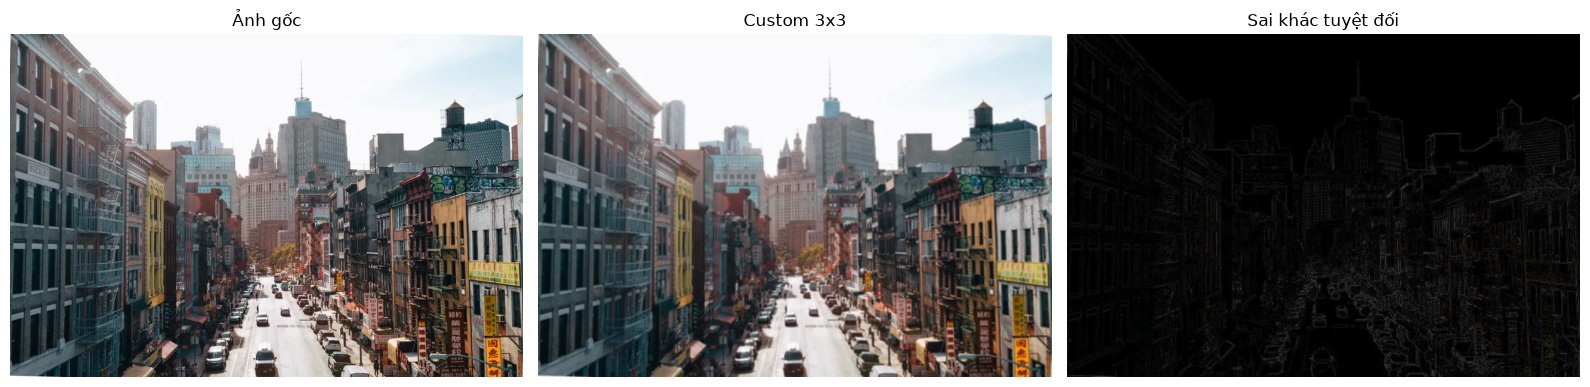

Custom: MSE=0.002125, edge energy=0.216446


In [36]:
custom_kernel = np.array([[1,2,1],[2,0,2],[1,2,1]], dtype=np.float32) / 12
print(custom_kernel)
print("Tổng trọng số:", custom_kernel.sum())
custom_rgb = cv2.filter2D(image_rgb, -1, custom_kernel, borderType=cv2.BORDER_REFLECT)
custom_gray = cv2.cvtColor(custom_rgb, cv2.COLOR_RGB2GRAY)
fig, axes = plt.subplots(1,3,figsize=(16,5))
for ax,img,title in zip(axes,[image_rgb,custom_rgb,cv2.absdiff(image_rgb,custom_rgb)],["Ảnh gốc","Custom 3x3","Sai khác tuyệt đối"]):
    ax.imshow(img); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()
print(f"Custom: MSE={normalized_mse(image_gray, custom_gray):.6f}, edge energy={edge_energy(custom_gray.astype(np.float32)/255):.6f}")

# Hàm hỗ trợ lưu kết quả

In [37]:
GENERATED_SUFFIXES = (
    "_mean.png", "_gaussian.png", "_laplacian.png",
    "_sobel.png", "_comparison.png", "_custom.png",
    "_custom_comparison.png", "metrics.csv",
)

In [38]:
def clear_results():
    """Xóa các kết quả do notebook tạo ở lần chạy trước."""
    removed = 0
    for path in OUTPUT_DIR.iterdir():
        if path.is_file() and path.name.endswith(GENERATED_SUFFIXES):
            path.unlink()
            removed += 1
    return removed

In [39]:
def save_comparison(name, images, titles):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, image, title in zip(axes.flat, images, titles):
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{name}_comparison.png", dpi=150)
    plt.close(fig)

# Áp dụng trên nhiều ảnh và lưu kết quả

## 1. Chuẩn bị thư mục output và danh sách metric

In [40]:
OUTPUT_DIR.mkdir(exist_ok=True)
removed = clear_results()
metrics_rows = []
batch_results = []
print(f"Đã xóa {removed} kết quả cũ.")

Đã xóa 18 kết quả cũ.


## 2. Chạy Mean và Gaussian trên từng ảnh

In [41]:
for input_path in image_paths:
    bgr = cv2.imread(str(input_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    name = input_path.stem

    mean = cv2.blur(rgb, (KERNEL_SIZE, KERNEL_SIZE))
    gaussian = cv2.GaussianBlur(
        rgb,
        (KERNEL_SIZE, KERNEL_SIZE),
        sigmaX=SIGMA,
        sigmaY=SIGMA,
        borderType=cv2.BORDER_REFLECT,
    )

    batch_results.append({
        "path": input_path,
        "name": name,
        "rgb": rgb,
        "gray": gray,
        "mean": mean,
        "gaussian": gaussian,
    })

print(f"Đã tạo kết quả low-pass cho {len(batch_results)} ảnh.")

Đã tạo kết quả low-pass cho 3 ảnh.


## 3. Chạy Laplacian và Sobel trên ảnh grayscale

In [42]:
for item in batch_results:
    gray = item["gray"]
    laplacian = cv2.convertScaleAbs(
        cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    )
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.convertScaleAbs(
        cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))
    )
    item["laplacian"] = laplacian
    item["sobel"] = sobel

print("Đã tạo kết quả high-pass.")

Đã tạo kết quả high-pass.


## 4. Lưu ảnh, áp dụng custom filter và tính metric

In [43]:
for item in batch_results:
    name = item["name"]
    rgb = item["rgb"]
    gray = item["gray"]

    cv2.imwrite(str(OUTPUT_DIR / f"{name}_mean.png"), cv2.cvtColor(item["mean"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_DIR / f"{name}_gaussian.png"), cv2.cvtColor(item["gaussian"], cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_DIR / f"{name}_laplacian.png"), item["laplacian"])
    cv2.imwrite(str(OUTPUT_DIR / f"{name}_sobel.png"), item["sobel"])
    save_comparison(
        name,
        [rgb, item["mean"], item["gaussian"], gray, item["laplacian"], item["sobel"]],
        ["Original", "Mean 5x5", "Gaussian 5x5", "Grayscale", "Laplacian", "Sobel"],
    )

    filtered = {
        "original": gray,
        "mean": cv2.cvtColor(item["mean"], cv2.COLOR_RGB2GRAY),
        "gaussian": cv2.cvtColor(item["gaussian"], cv2.COLOR_RGB2GRAY),
    }

    if item["path"].name.lower() == CUSTOM_IMAGE_NAME:
        custom = cv2.filter2D(rgb, -1, custom_kernel, borderType=cv2.BORDER_REFLECT)
        custom_gray = cv2.cvtColor(custom, cv2.COLOR_RGB2GRAY)
        filtered["custom"] = custom_gray
        cv2.imwrite(str(OUTPUT_DIR / f"{name}_custom.png"), cv2.cvtColor(custom, cv2.COLOR_RGB2BGR))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, image, title in zip(axes, [rgb, custom], ["Original", "Custom 3x3"]):
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / f"{name}_custom_comparison.png", dpi=150)
        plt.close(fig)

    for method, filtered_gray in filtered.items():
        metrics_rows.append({
            "image": name,
            "method": method,
            "mse_from_original": round(normalized_mse(gray, filtered_gray), 6),
            "edge_energy": round(edge_energy(filtered_gray.astype(np.float32) / 255), 6),
        })

## 5. Ghi metrics.csv

In [44]:
with (OUTPUT_DIR / "metrics.csv").open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(
        file,
        fieldnames=["image", "method", "mse_from_original", "edge_energy"],
    )
    writer.writeheader()
    writer.writerows(metrics_rows)

print(f"Đã xử lý {len(batch_results)} ảnh.")
print(f"Kết quả được lưu tại: {OUTPUT_DIR}")

Đã xử lý 3 ảnh.
Kết quả được lưu tại: /home/kiettran05/Documents/BTL_IPCV/cv-experiments-from-ipcv-vingroup/project_2/results


# Đọc bảng metric

In [45]:
with (OUTPUT_DIR / "metrics.csv").open(encoding="utf-8") as file:
    print(file.read())

image,method,mse_from_original,edge_energy
Landscape-fabric-under-gravel,original,0.0,0.554969
Landscape-fabric-under-gravel,mean,0.008186,0.298188
Landscape-fabric-under-gravel,gaussian,0.003768,0.37637
still_life,original,0.0,0.082706
still_life,mean,0.000299,0.045464
still_life,gaussian,0.000136,0.056131
urban,original,0.0,0.318799
urban,mean,0.00423,0.159224
urban,gaussian,0.00211,0.198451
urban,custom,0.002125,0.216446

